In [1]:
# Install all packages required for this talktorial
%pip install requests pandas rdkit

Note: you may need to restart the kernel to use updated packages.


In [2]:
import math
from pathlib import Path

import requests

import pandas as pd

# PandasTool is not required


In [3]:


HERE = Path(_dh[-1])
DATA = HERE / "data"



In [4]:
BASE_URL = "https://www.ebi.ac.uk/chembl/api/data"

# Function to get JSON data from a the ChEMBL REST endpoint, handling pagination 
def get_json(endpoint, params=None):
    params = params.copy() if params else {}
    params.setdefault("limit", 1000)

    records = []
    offset = 0

    while True:
        params["offset"] = offset

        response = requests.get(
            f"{BASE_URL}/{endpoint}.json",
            params=params,
            headers={"Accept": "application/json"},
            timeout=30,
        )

        response.raise_for_status()
        data = response.json()
        collection_name = next(
            key
            for key in data.keys()
            if isinstance(data[key], list)
        )

        batch = data[collection_name]

        if not batch:
            break

        records.extend(batch)

        if len(batch) < params["limit"]:
            break

        offset += params["limit"]

    return records


In [5]:
# Search for targets in chembl from uniprot_id and return a pandas DataFrame with the results
def get_targets(uniprot_id):
    targets = get_json(
        "target",
        {
            "target_components__accession": uniprot_id
        }
    )

    targets = pd.DataFrame(targets)

    # Add columns to the DataFrame if it is not empty
    if not targets.empty:
        columns = [
            "target_chembl_id",
            "organism",
            "pref_name",
            "target_type",
        ]

        targets = targets[columns]

    return targets

In [6]:
# Search for activities in chembl using a target_chembl_id and return a pandas DataFrame with the results
def get_activities(
    target_chembl_id,
    activity_type="Kd",
    relation="=",
    assay_type="B",
):

    activities = get_json(
        "activity",
        {
            "target_chembl_id": target_chembl_id,
            "standard_type": activity_type,
            "relation": relation,
            "assay_type": assay_type,
        },
    )

    activities = pd.DataFrame(activities)

    if not activities.empty:
        columns = [
            "activity_id",
            "assay_chembl_id",
            "assay_description",
            "assay_type",
            "molecule_chembl_id",
            "type",
            "standard_units",
            "relation",
            "standard_value",
            "target_chembl_id",
            "target_organism",
        ]

        available = [
            c for c in columns
            if c in activities.columns
        ]

        activities = activities[available]

    return activities


In [7]:
# Search for compounds in chembl using a list of molecule_chembl_ids and return a pandas DataFrame with the results
def get_compounds(molecule_chembl_ids, batch_size=100):

    molecule_chembl_ids = list(set(molecule_chembl_ids))
    compounds = []

    for start in range(0, len(molecule_chembl_ids), batch_size):
        batch = molecule_chembl_ids[start:start + batch_size]
        ids = ";".join(batch)

        data = get_json(
            f"molecule/set/{ids}"
        )
        for molecule in data:
            compounds.append(
                {
                    "molecule_chembl_id": molecule["molecule_chembl_id"],
                    "molecule_structures": molecule["molecule_structures"],
                }
            )

        print(
            f"Retrieved {len(compounds)} compounds...",
            end="\r"
        )

    return pd.DataFrame(compounds)

In [8]:
uniprot_id = "P14416"

In [9]:
# Get target information from ChEMBL but restrict it to specified values only
targets = get_targets(uniprot_id)

print(f"The type of targets is {type(targets)}")

The type of targets is <class 'pandas.DataFrame'>


In [10]:
# Let's have a look at the target information we retrieved from ChEMBL
targets.head()

,target_chembl_id,organism,pref_name,target_type
0,CHEMBL217,Homo sapiens,D(2) dopamine receptor,SINGLE PROTEIN
1,CHEMBL2095169,Homo sapiens,Dopamine receptors; D2 & D3,SELECTIVITY GROUP
2,CHEMBL2095396,Homo sapiens,Dopamine receptors; D2 & D4,SELECTIVITY GROUP
3,CHEMBL2096905,Homo sapiens,Dopamine receptor,PROTEIN FAMILY
4,CHEMBL2111460,Homo sapiens,Dopamine D2 receptor and serotonin 1a receptor,SELECTIVITY GROUP


In [11]:
target = targets.iloc[0]
target

target_chembl_id                 CHEMBL217
organism                      Homo sapiens
pref_name           D(2) dopamine receptor
target_type                 SINGLE PROTEIN
Name: 0, dtype: str

In [12]:
chembl_id = target.target_chembl_id
print(f"The target ChEMBL ID is {chembl_id}")

The target ChEMBL ID is CHEMBL217


In [13]:
bioactivities = get_activities(chembl_id)

print(
    f"Length and type of bioactivities object: "
    f"{len(bioactivities)}, {type(bioactivities)}"
)


Length and type of bioactivities object: 129, <class 'pandas.DataFrame'>


In [14]:
# Check the number of unique molecules
print(bioactivities["molecule_chembl_id"].nunique())

99


In [15]:
bioactivities.head()

,activity_id,assay_chembl_id,assay_description,assay_type,molecule_chembl_id,type,standard_units,relation,standard_value,target_chembl_id,target_organism
0,634391,CHEMBL671443,Equilibrium dissociation constant against reco...,B,CHEMBL24077,Kd,nM,=,9500.0,CHEMBL217,Homo sapiens
1,638001,CHEMBL671443,Equilibrium dissociation constant against reco...,B,CHEMBL53,Kd,nM,=,24.0,CHEMBL217,Homo sapiens
2,657116,CHEMBL671443,Equilibrium dissociation constant against reco...,B,CHEMBL225230,Kd,nM,=,20.0,CHEMBL217,Homo sapiens
3,1030540,CHEMBL672779,Compound was evaluated for the ability to disp...,B,CHEMBL276326,Kd,nM,=,6.75,CHEMBL217,Homo sapiens
4,1030541,CHEMBL669939,Compound was evaluated for the ability to disp...,B,CHEMBL276326,Kd,nM,=,728.0,CHEMBL217,Homo sapiens


In [16]:
bioactivities.dtypes

activity_id           int64
assay_chembl_id         str
assay_description       str
assay_type              str
molecule_chembl_id      str
type                    str
standard_units          str
relation                str
standard_value          str
target_chembl_id        str
target_organism         str
dtype: object

In [17]:
bioactivities = bioactivities.astype({"standard_value": "float64"})
bioactivities.dtypes

activity_id             int64
assay_chembl_id           str
assay_description         str
assay_type                str
molecule_chembl_id        str
type                      str
standard_units            str
relation                  str
standard_value        float64
target_chembl_id          str
target_organism           str
dtype: object

In [18]:
bioactivities.dropna(axis=0, how="any", inplace=True)
print(f"DataFrame shape: {bioactivities.shape}")

DataFrame shape: (129, 11)


In [19]:
print(f"Units in downloaded data: {bioactivities['standard_units'].unique()}")
print(
    f"Number of non-nM entries:\
    {bioactivities[bioactivities['standard_units'] != 'nM'].shape[0]}"
)

Units in downloaded data: <StringArray>
['nM']
Length: 1, dtype: str
Number of non-nM entries:    0


In [20]:
bioactivities = bioactivities[bioactivities["standard_units"] == "nM"]
print(f"Units after filtering: {bioactivities['standard_units'].unique()}")

Units after filtering: <StringArray>
['nM']
Length: 1, dtype: str


In [21]:
print(f"DataFrame shape: {bioactivities.shape}")

DataFrame shape: (129, 11)


In [22]:
bioactivities.drop_duplicates("molecule_chembl_id", keep="first", inplace=True)
print(f"DataFrame shape: {bioactivities.shape}")

DataFrame shape: (99, 11)


In [23]:
bioactivities.reset_index(drop=True, inplace=True)
bioactivities.head()

,activity_id,assay_chembl_id,assay_description,assay_type,molecule_chembl_id,type,standard_units,relation,standard_value,target_chembl_id,target_organism
0,634391,CHEMBL671443,Equilibrium dissociation constant against reco...,B,CHEMBL24077,Kd,nM,=,9500.00,CHEMBL217,Homo sapiens
1,638001,CHEMBL671443,Equilibrium dissociation constant against reco...,B,CHEMBL53,Kd,nM,=,24.00,CHEMBL217,Homo sapiens
2,657116,CHEMBL671443,Equilibrium dissociation constant against reco...,B,CHEMBL225230,Kd,nM,=,20.00,CHEMBL217,Homo sapiens
3,1030540,CHEMBL672779,Compound was evaluated for the ability to disp...,B,CHEMBL276326,Kd,nM,=,6.75,CHEMBL217,Homo sapiens
4,1031772,CHEMBL669940,Compound was evaluated for the ability to disp...,B,CHEMBL18598,Kd,nM,=,0.43,CHEMBL217,Homo sapiens


In [24]:
bioactivities.rename(
    columns={"standard_value": "Kd", "standard_units": "units"}, inplace=True
)
bioactivities.head()

,activity_id,assay_chembl_id,assay_description,assay_type,molecule_chembl_id,type,units,relation,Kd,target_chembl_id,target_organism
0,634391,CHEMBL671443,Equilibrium dissociation constant against reco...,B,CHEMBL24077,Kd,nM,=,9500.00,CHEMBL217,Homo sapiens
1,638001,CHEMBL671443,Equilibrium dissociation constant against reco...,B,CHEMBL53,Kd,nM,=,24.00,CHEMBL217,Homo sapiens
2,657116,CHEMBL671443,Equilibrium dissociation constant against reco...,B,CHEMBL225230,Kd,nM,=,20.00,CHEMBL217,Homo sapiens
3,1030540,CHEMBL672779,Compound was evaluated for the ability to disp...,B,CHEMBL276326,Kd,nM,=,6.75,CHEMBL217,Homo sapiens
4,1031772,CHEMBL669940,Compound was evaluated for the ability to disp...,B,CHEMBL18598,Kd,nM,=,0.43,CHEMBL217,Homo sapiens


In [25]:
print(f"DataFrame shape: {bioactivities.shape}")

DataFrame shape: (99, 11)


In [26]:
print(len(bioactivities))
print(bioactivities["molecule_chembl_id"].nunique())

99
99


In [27]:
compounds = get_compounds(bioactivities["molecule_chembl_id"].unique())

In [28]:
compounds.head()

,molecule_chembl_id,molecule_structures
0,CHEMBL390297,{'canonical_smiles': 'CN1C[C@H](C(=O)N[C@@H](C...
1,CHEMBL4576998,{'canonical_smiles': 'O=C(CCCN1CCC(O)(c2ccc(Cl...
2,CHEMBL5206565,{'canonical_smiles': 'N/C(=N\C(=O)NCc1ccccc1)N...
3,CHEMBL4475608,{'canonical_smiles': 'Cc1ccccc1C(=O)CCCN1CCC(O...
4,CHEMBL54206,{'canonical_smiles': 'O=C(CCCN1CCC(O)(c2ccccc2...


In [29]:
compounds.dropna(axis=0, how="any", inplace=True)
print(f"DataFrame shape: {compounds.shape}")

DataFrame shape: (99, 2)


In [30]:
print(f"Bioactivities filtered: {bioactivities.shape[0]}")
bioactivities.columns

Bioactivities filtered: 99


Index(['activity_id', 'assay_chembl_id', 'assay_description', 'assay_type',
       'molecule_chembl_id', 'type', 'units', 'relation', 'Kd',
       'target_chembl_id', 'target_organism'],
      dtype='str')

In [31]:
print(f"Compounds filtered: {compounds.shape[0]}")
compounds.columns

Compounds filtered: 99


Index(['molecule_chembl_id', 'molecule_structures'], dtype='str')

In [32]:
# Merge DataFrames
output_df = pd.merge(
    bioactivities[["molecule_chembl_id", "Kd", "units"]],
    compounds,
    on="molecule_chembl_id",
)

# Reset row indices
output_df.reset_index(drop=True, inplace=True)

print(f"Dataset with {output_df.shape[0]} entries.")

Dataset with 99 entries.


In [33]:
output_df.dtypes

molecule_chembl_id         str
Kd                     float64
units                      str
molecule_structures     object
dtype: object

In [34]:
output_df.head(10)

,molecule_chembl_id,Kd,units,molecule_structures
0,CHEMBL24077,9500.000,nM,{'canonical_smiles': 'Oc1cc2c(cc1O)[C@@H](c1cc...
1,CHEMBL53,24.000,nM,{'canonical_smiles': 'CN1CCc2cccc3c2[C@H]1Cc1c...
2,CHEMBL225230,20.000,nM,{'canonical_smiles': 'CCCN1CCc2cccc3c2[C@H]1Cc...
3,CHEMBL276326,6.750,nM,{'canonical_smiles': 'CN1CCc2cc(Br)cc3c2[C@H]1...
4,CHEMBL18598,0.430,nM,{'canonical_smiles': 'CN1CCc2cc(F)cc3c2[C@H]1C...
5,CHEMBL276042,19.900,nM,{'canonical_smiles': 'CN1CCc2cc(N)cc3c2[C@H]1C...
6,CHEMBL19130,1.100,nM,{'canonical_smiles': 'CN1CCc2cc(O)cc3c2[C@H]1C...
7,CHEMBL267932,0.097,nM,{'canonical_smiles': 'CN1CN(c2ccccc2)C2(CCN(CC...
8,CHEMBL388509,16000.000,nM,{'canonical_smiles': 'CC(C)[C@H](NC(=O)[C@@H]1...
9,CHEMBL390297,300.000,nM,{'canonical_smiles': 'CN1C[C@H](C(=O)N[C@@H](C...


In [35]:
def convert_kd_to_pkd50(Kd_value):
    pKd_value = 9 - math.log10(Kd_value)
    return pKd_value

In [36]:
# Apply conversion to each row of the compounds DataFrame
output_df["pKd"] = output_df.apply(lambda x: convert_kd_to_pkd50(x.Kd), axis=1)

In [37]:
output_df.head()

,molecule_chembl_id,Kd,units,molecule_structures,pKd
0,CHEMBL24077,9500.00,nM,{'canonical_smiles': 'Oc1cc2c(cc1O)[C@@H](c1cc...,5.022276
1,CHEMBL53,24.00,nM,{'canonical_smiles': 'CN1CCc2cccc3c2[C@H]1Cc1c...,7.619789
2,CHEMBL225230,20.00,nM,{'canonical_smiles': 'CCCN1CCc2cccc3c2[C@H]1Cc...,7.698970
3,CHEMBL276326,6.75,nM,{'canonical_smiles': 'CN1CCc2cc(Br)cc3c2[C@H]1...,8.170696
4,CHEMBL18598,0.43,nM,{'canonical_smiles': 'CN1CCc2cc(F)cc3c2[C@H]1C...,9.366532


array([[<Axes: title={'center': 'pKd'}>]], dtype=object)

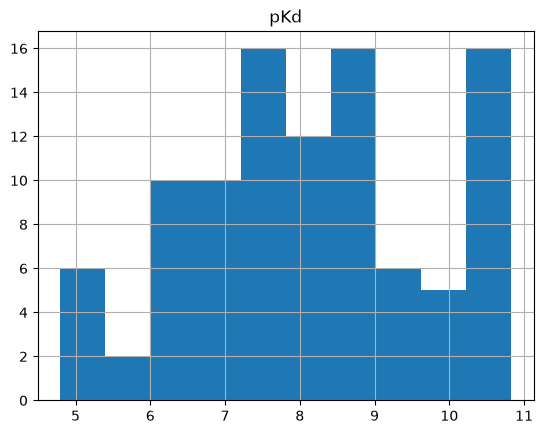

In [47]:
output_df.hist(column="pKd")


In [39]:
from rdkit import Chem

#Deze heb ik veranderd met copilot, belangrijk om na te checken
#Add molecule column
# Extract SMILES from the ChEMBL structure dictionaries
output_df["smiles"] = output_df["molecule_structures"].apply(
    lambda structure: structure.get("canonical_smiles")
    if isinstance(structure, dict)
    else None
)

# Add RDKit molecule objects
output_df["ROMol"] = output_df["smiles"].apply(
    lambda smiles: Chem.MolFromSmiles(smiles) if pd.notna(smiles) else None
)

In [40]:
# Sort molecules by pKd
output_df.sort_values(by="pKd", ascending=False, inplace=True)

# Reset index
output_df.reset_index(drop=True, inplace=True)

In [41]:
output_df.drop("smiles", axis=1).head(3)

,molecule_chembl_id,Kd,units,molecule_structures,pKd,ROMol
0,CHEMBL5176229,0.0149,nM,{'canonical_smiles': 'N/C(=N\C(=O)NCCCCCCNC(=O...,10.826814,<rdkit.Chem.rdchem.Mol object at 0x127cdb760>
1,CHEMBL301265,0.0149,nM,{'canonical_smiles': 'CCCN[C@H]1CCc2nc(N)sc2C1...,10.826814,<rdkit.Chem.rdchem.Mol object at 0x127cdb1b0>
2,CHEMBL5183205,0.0149,nM,{'canonical_smiles': 'CCCCCNC(=O)/N=C(\N)NCCCc...,10.826814,<rdkit.Chem.rdchem.Mol object at 0x127cdb290>


In [42]:
# Prepare saving the dataset: Drop the ROMol column
output_df = output_df.drop("ROMol", axis=1)
print(f"DataFrame shape: {output_df.shape}")

DataFrame shape: (99, 6)


In [43]:
#Deze heb ik veranderd met copilot, belangrijk om na te checken
# Disable this cell to unfreeze the dataset
dataset_path = DATA / "DopamineD2_compounds_Kd.csv"

if dataset_path.exists():
    output_df = pd.read_csv(
        dataset_path,
        float_precision="round_trip",
    )
else:
    print(f"{dataset_path} not found; using the generated dataset.")
output_df.head()

,molecule_chembl_id,Kd,units,molecule_structures,pKd,smiles
0,CHEMBL5176229,0.0149,nM,{'canonical_smiles': 'N/C(=N\\C(=O)NCCCCCCNC(=...,10.826814,N/C(=N\C(=O)NCCCCCCNC(=O)/N=C(\N)NCCCc1nnc(N)s...
1,CHEMBL301265,0.0149,nM,{'canonical_smiles': 'CCCN[C@H]1CCc2nc(N)sc2C1...,10.826814,CCCN[C@H]1CCc2nc(N)sc2C1
2,CHEMBL5183205,0.0149,nM,{'canonical_smiles': 'CCCCCNC(=O)/N=C(\\N)NCCC...,10.826814,CCCCCNC(=O)/N=C(\N)NCCCc1cnc(N)s1.O=C(O)C(F)(F...
3,CHEMBL5200771,0.0149,nM,{'canonical_smiles': 'CCCCCCNC(=O)/N=C(\\N)NCC...,10.826814,CCCCCCNC(=O)/N=C(\N)NCCCc1nnc(N)s1.O=C(O)C(F)(...
4,CHEMBL5204599,0.0149,nM,{'canonical_smiles': 'CC(CNC(=O)/N=C(\\N)NCCCc...,10.826814,CC(CNC(=O)/N=C(\N)NCCCc1nnc(N)s1)C1CCCCC1.O=C(...


In [44]:
print(f"DataFrame shape: {output_df.shape}")
# NBVAL_CHECK_OUTPUT

DataFrame shape: (99, 6)


In [45]:
#Deze heb ik veranderd met copilot, belangrijk om na te checken
DATA.mkdir(parents=True, exist_ok=True)
output_df.to_csv(DATA / "DopamineD2_compounds_Kd.csv", index=False)

output_df.head()
output_df.head()

,molecule_chembl_id,Kd,units,molecule_structures,pKd,smiles
0,CHEMBL5176229,0.0149,nM,{'canonical_smiles': 'N/C(=N\\C(=O)NCCCCCCNC(=...,10.826814,N/C(=N\C(=O)NCCCCCCNC(=O)/N=C(\N)NCCCc1nnc(N)s...
1,CHEMBL301265,0.0149,nM,{'canonical_smiles': 'CCCN[C@H]1CCc2nc(N)sc2C1...,10.826814,CCCN[C@H]1CCc2nc(N)sc2C1
2,CHEMBL5183205,0.0149,nM,{'canonical_smiles': 'CCCCCNC(=O)/N=C(\\N)NCCC...,10.826814,CCCCCNC(=O)/N=C(\N)NCCCc1cnc(N)s1.O=C(O)C(F)(F...
3,CHEMBL5200771,0.0149,nM,{'canonical_smiles': 'CCCCCCNC(=O)/N=C(\\N)NCC...,10.826814,CCCCCCNC(=O)/N=C(\N)NCCCc1nnc(N)s1.O=C(O)C(F)(...
4,CHEMBL5204599,0.0149,nM,{'canonical_smiles': 'CC(CNC(=O)/N=C(\\N)NCCCc...,10.826814,CC(CNC(=O)/N=C(\N)NCCCc1nnc(N)s1)C1CCCCC1.O=C(...


In [46]:
print(f"DataFrame shape: {output_df.shape}")
# NBVAL_CHECK_OUTPUT

DataFrame shape: (99, 6)
